In [2]:
import numpy as np
import pandas as pd
import math

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader     # Batches + shuffling + iteration over datasets
from torchvision import datasets, transforms # Ready-to-use datasets + image transformations


import matplotlib.pyplot as plt             # Plotting loss curves


In [3]:
# why do we need PatchEmbedding to be a nn.Module? It contains leanable parameters.
# we are telling PyTorch to keep track of these parameters for us.
# and that this module contains learnable parameters and maybe even sub-modules.
# and we are telling PyTorch to keep track of these parameters for us.
# it is also a reusable component that can be easily integrated into larger models.
class PatchEmbedding(nn.Module):
    def __init__(
        self,
        img_size=224, # input image size (H and W are assumed to be equal)
        patch_size=16, # patch size (H and W will be divided by this number to get the number of patches)
        in_chans=3, # number of input channels (3 for RGB images)
        embed_dim=768, # embedding dimension (output dimension of each patch embedding
    ):
        super().__init__() # initialize the parent class nn.Module
        # a quick sanity check
        # NOTE that we are assuming non-overlapping patches here
        # Image must divide evenly into patches
        # why do we need assert here? 
        # to catch errors early and provide meaningful error messages.
        assert img_size % patch_size == 0, "Image size must be divisible by patch size."

        self.img_size = img_size
        self.patch_size = patch_size
        # calculate number of patches
        # this is a metadata we might need later for cls tokens and positional embeddings
        # it is not a learnable parameter, so we just store it as a regular attribute
        self.num_patches = (img_size // patch_size) * (img_size // patch_size)

        # now the big part: defining the projection with learnable parameters
        # this is defined as a Conv2d layer 
        # to make sure that the patches are non-overlapping,
        # we set the kernel size and stride to be equal to patch_size
        self.proj = nn.Conv2d(
            in_channels=in_chans,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
            bias=False, # no bias term? can be set to True if needed
        )
        # what parameters does this layer create?
        # self.proj.weight  # shape: (embed_dim, in_chans, patch_size, patch_size)
        # self.proj.bias    # None, since bias=False
        
        # add cls token
        # the dimensions are (1, 1, embed_dim)
        # meaning there is one shared cls token across the batch
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # define the learnable positional embeddings
        # num_patches + 1 to account for cls token
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches+1, embed_dim))
    def forward(self, x):
        """forward pass through the Patch Embedding layer"""
        # as said earlier, this basically defines what happens when the input 
        # passes through the PatchEmbedding layer
        # apply the patch projection
        x = self.proj(x)  # shape: (B, embed_dim, H/patch_size, W/patch_size)

        # flatten the spatial dimensions, the spatial grid, (H/patch_size, W/patch_size) into one dimension
        x = x.flatten(2)  # shape: (B, embed_dim, num_patches)
        # transpose to get the final shape
        # the final shape would be (B, num_patches, embed_dim)
        x = x.transpose(1, 2)  # shape: (B, num_patches, embed_dim)

        # Expand CLS token across batch
        # We want to prepend one CLS token to each image in the batch.
        # That means we need B copies of the CLS token one per image.
        # We now need to logically turn: (1, 1, embed_dim) -> (B, 1, embed_dim)
        B = x.shape[0]
        cls_tokens = self.cls_token.expand(B, -1, -1)
        # shape: (B, 1, embed_dim)

        # Prepend CLS token
        x = torch.cat((cls_tokens, x), dim=1)
        # shape: (B, num_patches + 1, embed_dim)

        # add positional embeddings
        x = x + self.pos_embed  # shape: (B, num_patches + 1, embed_dim)
        return x
    
# testing the PatchEmbedding module
if __name__ == "__main__":
    # create a random input image tensor
    img_size = 224
    patch_size = 16
    in_chans = 3
    embed_dim = 768
    batch_size = 2

    x = torch.randn(batch_size, in_chans, img_size, img_size)  # shape: (B, C, H, W)

    # create the PatchEmbedding module
    patch_embedding = PatchEmbedding(
        img_size=img_size,
        patch_size=patch_size,
        in_chans=in_chans,
        embed_dim=embed_dim,
    )

    # forward pass
    out = patch_embedding(x)  # shape: (B, num_patches + 1, embed_dim)

    print("Input shape:", x.shape)
    print("Output shape:", out.shape)
    # expected output shape: (B, num_patches + 1, embed_dim)
    num_patches = (img_size // patch_size) * (img_size // patch_size)
    expected_shape = (batch_size, num_patches + 1, embed_dim)
    assert out.shape == expected_shape, f"Expected shape {expected_shape}, but got {out.shape}"
    print("PatchEmbedding module works correctly!")

Input shape: torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 197, 768])
PatchEmbedding module works correctly!


In [4]:
class MultiHeadSelfAttention(nn.Module):
    """
    Multi-head self-attention module.
    Input:  x of shape (B, N, D)
    Output:     shape (B, N, D)
    """

    def __init__(self, embed_dim: int, num_heads: int, attn_drop: float = 0.1, proj_drop: float = 0.1):
        """_summary_

        Args:
            embed_dim (int): embedding dimension
            num_heads (int): number of attention heads
            attn_dropout (float, optional): regularization! What percentage of attention weights to drop. Defaults to 0.1.
            proj_dropout (float, optional): regularization! What percentage of output projection weights to drop. Defaults to 0.1.
        """
        # we have multiple heads of self-attention
        # each head has its own set of learnable parameters
        # parameters are weight matrices for query, key, value, and output projection
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads

        # now we need to assert that embed_dim is divisible by num_heads
        assert embed_dim % num_heads == 0, "Embedding dimension must be divisible by number of heads."
        # why is it important?
        # because output of each head will have a dimension of embed_dim // num_heads
        # in other words, each attention head will take the whole embedding vector
        # and project it down to a smaller dimension of embed_dim // num_heads
        self.head_dim = embed_dim // num_heads

        # Attention uses dot products Q·K.
        # Dot products grow with dimension, so we scale by 1/sqrt(d) for stability.
        self.scale = 1.0 / math.sqrt(self.head_dim)

        # define the learnable parameters
        # we can use nn.Linear to define the weight matrices for query, key, value, and output projection
        # each of these layers will have its own weight matrix
        # One Linear layer to create Q, K, V together.
        # Input per token:  D
        # Output per token: 3D  (concatenated Q, K, V)
        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=False)

        # dropout for attention weights
        self.attn_dropout = nn.Dropout(attn_drop)

        # After combining head outputs, we apply a final projection back to D.
        # WHY? because each head outputs a vector of size head_dim
        # and we have num_heads of them, so we need to combine them back to embed_dim
        # but why is 
        self.proj = nn.Linear(embed_dim, embed_dim, bias=True)

        # dropout for output projection
        self.proj_dropout = nn.Dropout(proj_drop)

    def forward(self, x: torch.Tensor)-> torch.Tensor:

        """forward pass through the Multi-head self-attention module"""

        # x is expected to be (B, N, D)
        B, N, D = x.shape  # unpack batch size, number of tokens, embedding dimension

        # Compute Q, K, V for all tokens in one matrix multiplication.
        # qkv shape: (B, N, 3D) q, k, and v are concatenated along the last dimension
        qkv = self.qkv(x)

        # first Reshape to separate Q/K/V and heads:
        # (B, N, 3D) -> (B, N, 3, H, d)
        qkv = qkv.view(B, N, 3, self.num_heads, self.head_dim)

        # Permute dimensions so Q/K/V become the first index:
        # (B, N, 3, H, d) -> (3, B, H, N, d)
        qkv = qkv.permute(2, 0, 3, 1, 4)

        # Split into q, k, v:
        # each is shape (B, H, N, d)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # first Compute attention scores:
        # For each head, scores = Q @ K^T
        # q: (B, H, N, d)
        # k.transpose(-2, -1): (B, H, d, N)
        # scores: (B, H, N, N)
        # note that self.scale is defined in __init__
        # it is 1/sqrt(head_dim)
        # why k.transfose(-2, -1)? 
        # because we want to do dot product between each query and all keys
        # for transpose, -2 refers to the second last dimension
        # -1 refers to the last dimension
        # .transpose simply swaps these two dimensions
        # a simple .T doesn't work here because tensors can have more than 2 dimensions
        # in this case, we have 4 dimensions: (B, H, N, d)
        # so with .transpose we need to specify which two dimensions to swap
        scores = (q @ k.transpose(-2, -1)) * self.scale

        # calculate attention weights by applying softmax to scores
        attn_weights = F.softmax(scores, dim=-1)

        # dropout on attention weights for regularization
        attn_weights = self.attn_dropout(attn_weights)

        # Weighted sum of values:
        # weights: (B, H, N, N)
        # v:       (B, H, N, d)
        # out:     (B, H, N, d)
        out = attn_weights @ v

        # Reorder so tokens come before heads:
        # (B, H, N, d) -> (B, N, H, d)
        # in pytorch, .transpose(dim0, dim1) swaps two dimensions
        # here we are swapping dimension 1 and 2
        out = out.transpose(1, 2)

        # Merge heads back into the full embedding dimension:
        # (B, N, H, d) -> (B, N, D)
        out = out.reshape(B, N, D)

        # Final linear projection to mix information across heads.
        out = self.proj(out)

        # dropout on output projection for regularization
        out = self.proj_dropout(out)

        return out
        

class MLP(nn.Module):
    """
    Transformer MLP / FeedForward network.
    Applied independently to each token (no token-to-token mixing).
    Think: with MHSA, we mix information across tokens;
    here, MLP is just a transformation applied to each token separately. 
    so no mixing happens here.
    Input:  (B, N, D)
    Output: (B, N, D)
    """
    # consider two linear layers with a non-linearity in between
    def __init__(self, embed_dim: int, mlp_ratio: float = 4.0, drop: float =0.1):
        super().__init__()

        self.embed_dim = embed_dim
        # Hidden dimension is typically 4x embedding dim in Transformers (a common default).
        hidden_dim = int(embed_dim * mlp_ratio)

        # note that the MLP is simply a bunch of linear layers with non-linearities in between
        # First linear expands the feature dimension: D -> hidden_dim.
        self.fc1 = nn.Linear(embed_dim, hidden_dim)

        # GELU is a smooth nonlinearity commonly used in Transformers.
        # this can also be ReLU, LeakyReLU, etc.
        self.act = nn.GELU()

        # now the regularization after the activation
        self.dropout1 = nn.Dropout(drop)

        # now the second layer to project back to embed_dim
        self.fc2 = nn.Linear(hidden_dim, embed_dim)

        # why is there no activation after the second linear layer?
        # The second linear layer in the MLP is meant to be a projection, 
        # not a feature extractor, so we do not put a nonlinearity after it.
        # so its main job is to map the hidden representation back to the original embedding dimension.
        # expand → nonlinearity → compress

        # another dropout after the second linear layer
        self.dropout2 = nn.Dropout(drop)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """forward pass through the MLP module"""
        # x is expected to be (B, N, D)
        x = self.fc1(x)          # (B, N, hidden_dim)
        x = self.act(x)         # (B, N, hidden_dim)
        x = self.dropout1(x)    # (B, N, hidden_dim)
        x = self.fc2(x)         # (B, N, D)
        x = self.dropout2(x)    # (B, N, D)
        return x


class TransformerEncoderBlock(nn.Module):
    """
    A full Transformer encoder block (ViT-style), using Pre-LayerNorm:
      x = x + Attention(LN(x))
      x = x + MLP(LN(x))

    Input:  (B, N, D)
    Output: (B, N, D)
    """
    # this is the full block with MSA and MLP with skip connections and layer norms
    def __init__(self,
        embed_dim: int,
        num_heads: int,
        mlp_ratio: float = 4.0,
        attn_drop: float = 0.0,
        proj_drop: float = 0.0,
        mlp_drop: float = 0.0,
    ):
        super().__init__()

        # LayerNorm normalizes each token's features (across D).
        # Pre-LN means we normalize BEFORE attention/MLP.
        # this is a layer normalization layer (not a batch normalization)
        # meaning this will do a normalization across the feature dimension for each token
        # as opposed to batch normalization which normalizes across the batch dimension
        self.norm1 = nn.LayerNorm(embed_dim)

        # now create an instance of MultiHeadSelfAttention
        # Multi-head self-attention sublayer.
        self.attn = MultiHeadSelfAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            attn_drop=attn_drop,
            proj_drop=proj_drop,
        )

        # note that you do not hit run here yet. You are just providing the recepie

        # Second LayerNorm before the MLP sublayer.
        self.norm2 = nn.LayerNorm(embed_dim)

        # now create an instance of MLP
        # MLP / FeedForward sublayer.
        self.mlp = MLP(embed_dim=embed_dim, mlp_ratio=mlp_ratio, drop=mlp_drop)

        # NOTE: skip connections/residual connections are implemented in the forward pass
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """forward pass through the Transformer Encoder Block"""
        # x is expected to be (B, N, D) 
        # ---- Attention sublayer (Pre-LN + residual) ----
        x = x + self.attn(self.norm1(x))
        # Explanation:
        # 1) self.norm1(x): normalize token features (stabilizes learning)
        # 2) self.attn(...): tokens mix information via attention
        # 3) x + ...       : residual connection keeps original info and adds an update

        # ---- MLP sublayer (Pre-LN + residual) ----
        x = x + self.mlp(self.norm2(x))
        # Explanation:
        # 1) self.norm2(x): normalize again before MLP
        # 2) self.mlp(...): per-token nonlinear feature transformation
        # 3) x + ...      : residual connection again
        return x

In [5]:
# build a full transformer encoder with multiple blocks
class VisionEncoder(nn.Module):
    """
    Full ViT-style encoder:
      image -> patch embedding -> transformer blocks -> tokens
    """
    def __init__(
        self,
        img_size=224,
        patch_size=16,
        in_chans=3,
        embed_dim=384,
        num_heads=12,
        mlp_ratio=4.0,
        depth=1,                 # number of transformer blocks
        attn_drop=0.1,
        proj_drop=0.1,
        mlp_drop=0.1,
    ):
        super().__init__()

        # 1) Patch embedding: images -> tokens
        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
        )

        # 2) Stack of Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                attn_drop=attn_drop,
                proj_drop=proj_drop,
                mlp_drop=mlp_drop,
            )
            for _ in range(depth)
        ])

    def forward(self, x):
        """
        x: (B, 3, H, W)
        returns: (B, N, D)
        """
        # images -> tokens
        x = self.patch_embed(x)      # (B, N, D)

        # tokens -> tokens
        for block in self.blocks:
            x = block(x)

        return x


training: we update the parameters so that the output of the model becomes more useful for a task. This (iterative) process of updating the parameters is trainig. 

Training always consists of:
1. a forward pass through the model: Input → model → output
2. Loss computation: calculating how "bad" the output is
3. backward pass to calculate gradients: in what direction should I change the parameters so that the output gets closer to the desired output
4. Parameter update: use the calculated gradient and an optimizer to update the parameters. 


During training, everything defined as nn.Parameter, nn.Linear, nn.LayerNorm, nn.Conv2d will be updated.

- nn.Conv2d: the kernels to be convolved with the image will be learnable. To put it in the context of Signals & Systems, this is what you are dealing with: “I don’t know the system’s impulse response yet — let me learn it from data.”
- nn.LayerNorm: this first does a standard normalization using statistics (mean and sd). Then it applies an affine transformation. This affine transformation is learnable. NOTE that this is an **affine** transformation that does not transfer the data into a lower dimension or another space, it is a simple scale and offset operation: y[i] = gamma[i] * x[i] + beta[i]. the affine transformation is learnable per-feature parameters




### Supervised vs unsupervised/self-supervised learning
XXX


unsupervised/self-supervised:
- invent a task like:
    - predict part of the image from another part
    - make representations of augmented views similar
    - reconstruct input (application: increasing the resolution of the image?)


#### training the encoder through supervised learning

Here, we try to train the encoder we built using an online dataset. 

We load in the dataset, and the first thing we do is to divide the dataset into train and test. We usually use only a subset for training and then test the model on the set of data it has never seen during training to see if it can generalize. Generalization is very important and that's why we hold out a set for testing the generalization.

some datasets already provide train and test sets but we can also divide the dataset manually into train and test sets. 

Our model also expects the images to be in a specific format so we need to make sure of that. 
Sometimes we need to apply a specific set of transformation to the images before they are ready to get fed into the model. These transformations can be as simple as resizing and converting to tensors to more complicated stuff. 

In [6]:
# ----------------------------
# 1) Reproducibility (optional but nice for teaching)
# ----------------------------

torch.manual_seed(0)                        # Makes random ops (like init/shuffle) more repeatable

In [7]:
# ----------------------------
# 2) Device selection (CPU-only on purpose)
# ----------------------------
# if you have a GPU and want to use it, you can change this to "cuda" or "cuda:0"
# if you are not sure, you can check if torch.cuda.is_available() returns True, and if so, set device to "cuda"
# check if cuda is available and set device accordingly
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")                # Force CPU so it runs on laptops without GPU


print("Using device:", device)

Using device: cpu


In [8]:
# ----------------------------
# 3) Image transforms (how images become tensors the model can consume)
# ----------------------------

# making sure the images are transformed to the format that our model expects
# we do this using a compose transform
# this can involve a set of transformations like resizing, normalization, etc.
# this is a very simple example which just resizes the image and converts it to a tensor

transform = transforms.Compose([            # Compose applies these transforms in order
    transforms.Resize(224),                 # Resize each image to 224x224 (ViT-style size)
    transforms.ToTensor(),                  # Convert PIL image [0..255] to float tensor [0..1]
    # Note: You can add normalization later; keeping it simple for the first demo.
])

In [9]:
# load the data that we will be using for training and testing
# most datasets come with predefined train/test splits, so we can just load them using torchvision.datasets

# ----------------------------
# 4) Option A: Load train/test provided by the dataset (CIFAR-10 has this)
# ----------------------------

train_dataset = datasets.CIFAR10(           # Download/load CIFAR-10 training split
    root="./data",                          # Where data will be stored on disk
    train=True,                             # Use training split
    download=True,                          # Download if not already present
    transform=transform,                    # Apply transforms to every image when loaded
)

test_dataset = datasets.CIFAR10(            # Download/load CIFAR-10 test split
    root="./data",                          # Same root directory
    train=False,                            # Use test split
    download=True,                          # Download if not already present
    transform=transform,                    # Same transform so shapes match
)

# alternatively you can manually split the dataset into train and test sets
# this will come in handy when you are working with custom datasets that do not have predefined splits
# or when you want to divide the data to custom splits for cross validation, etc.


/Users/lshahsha/Documents/GitHub/model_tutorial/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [10]:
# now let's take a look at the dataset and see what it looks like
print(dir(train_dataset))  # check the attributes and methods of the dataset object
print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))


y_train = train_dataset.targets  # list of labels for training data
y_test = test_dataset.targets    # list of labels for test data


print(type(y_train), type(y_test))  # check the type of the labels
print("Unique classes in training set:", set(y_train))
print("Unique classes in test set:", set(y_test))

['__add__', '__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_check_integrity', '_format_transform_repr', '_is_protocol', '_load_meta', '_repr_indent', 'base_folder', 'class_to_idx', 'classes', 'data', 'download', 'extra_repr', 'filename', 'meta', 'root', 'target_transform', 'targets', 'test_list', 'tgz_md5', 'train', 'train_list', 'transform', 'transforms', 'url']
Number of training samples: 50000
Number of test samples: 10000
<class 'list'> <class 'list'>
Unique classes in training set: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
Unique classes in test set: {0, 1, 2, 3, 4, 5, 6

In [11]:
# ----------------------------
# 5) DataLoaders (why we need them, and what each argument does)
# ----------------------------

train_loader = DataLoader(
    dataset=train_dataset,                  # The dataset to iterate over
    batch_size=20,                           # How many samples per batch (small for CPU)
    shuffle=True,                           # Randomize sample order each epoch (helps training)
    num_workers=0,                          # 0 = load data in the main process (simple, portable)
    pin_memory=False,                       # Mostly useful for GPU; keep False for CPU
)

test_loader = DataLoader(
    dataset=test_dataset,                   # The dataset to evaluate on
    batch_size=20,                           # Batch size for evaluation too
    shuffle=False,                          # No need to shuffle test data
    num_workers=0,                          # Keep it simple
    pin_memory=False,                       # CPU
)


In [12]:
# let's take a look at one batch of data from the train_loader
# you can see that the size is (B, C, H, W) for images and (B,) for labels
# you can also see that the transforms we defined earlier are applied to the images
print(type(train_loader))
# train_loader and test_loader are instances of DataLoader class
# NOTE that DataLoader is an iterable
# it is not subscriptable like a list or a tensor
# so you cannot do train_loader[0]
# instead, you can create an iterator over the DataLoader
data_iter = iter(train_loader)             # Create an iterator over the DataLoader
print(type(data_iter))                     # This is a DataLoader iterator
# data_iter is not subscriptable either
# so how do we get a batch from it?
# say we want the third batch
# we can call next() on the iterator three times
images1, labels1 = next(data_iter)           # Get the first batch
images2, labels2 = next(data_iter)           # Get the second batch
images3, labels3 = next(data_iter)           # Get the third batch
print("Batch image tensor shape:", images2.shape)  # Expected: (B, C, H, W)
print("Batch labels tensor shape:", labels2.shape)  # Expected: (B,)
print("Labels in this batch:", labels2.tolist())    # Print the actual labels in this batch

<class 'torch.utils.data.dataloader.DataLoader'>
<class 'torch.utils.data.dataloader._SingleProcessDataLoaderIter'>
Batch image tensor shape: torch.Size([20, 3, 224, 224])
Batch labels tensor shape: torch.Size([20])
Labels in this batch: [6, 4, 3, 9, 2, 8, 4, 9, 1, 3, 7, 3, 9, 0, 3, 8, 9, 5, 7, 3]


## Classifier head
NOTE that the encoder we've defined is supposed to extract features from the images. Features that are relevent for the task at hand. In this simple example, the task is categorization/classification.


In [13]:
# ----------------------------
# 6) Model: encoder + a classification head (encoder is TRAINED, not frozen)
# ----------------------------

class ClassifierHead(nn.Module):             # Define a model class that wraps your encoder
    def __init__(self, encoder, embed_dim, num_classes):
        super().__init__()                  # Initialize nn.Module internals
        self.encoder = encoder              # Store your encoder (trainable by default)
        self.head = nn.Linear(embed_dim, num_classes)  # Map CLS embedding -> class logits

    def forward(self, x):
        print(f"x shape in ClassifierHead forward: {x.shape}")
        tokens = self.encoder(x)            # (B, N, D): run image through encoder
        print(f"tokens shape after encoder: {tokens.shape}")
        # get the cls token
        cls = tokens[:, 0]                  # (B, D): take CLS token (global summary)
        print(f"cls token shape: {cls.shape}")
        logits = self.head(cls)             # (B, num_classes): raw class scores
        return logits                       # Return logits (CrossEntropyLoss expects logits)


In [14]:
# ----------------------------
# 7) Instantiate the model
# ----------------------------

# It must output tokens shaped (B, N, D).
# first create an instance of your encoder
encoder = VisionEncoder(
    img_size=224,
    patch_size=16,
    in_chans=3,
    embed_dim=384,
    num_heads=12,
    depth=12,          # keep small for CPU
)

model = ClassifierHead(
    encoder=encoder,                        # your trainable encoder module
    embed_dim=384,                          # D: must match encoder embedding dimension
    num_classes=10,                         # CIFAR-10 has 10 categories
).to(device)                                # Move model parameters to CPU (device)


In [15]:
# ----------------------------
# 8) Loss function and optimizer (what training is optimizing)
# ----------------------------
# we need to define a loss function and an optimizer for training
# during training, the model will try to minimize the loss function
# and the optimizer will update the model parameters based on the gradients of the loss function
# in this example, we will use CrossEntropyLoss and Adam optimizer
criterion = nn.CrossEntropyLoss()           # For multi-class classification with integer labels
optimizer = torch.optim.Adam(               # Adam optimizer (good default for Transformers)
    model.parameters(),                     # IMPORTANT: includes encoder + head parameters
    lr=1e-4                                 # Learning rate (small-ish; stable for beginners)
)

There are a few concepts you need to learn for training:

**Dataset**

a dataset is a full set of samples. For example, CIFAR-10 is a full dataset that contains 50,000 training samples. A dataset is a list of samples and their labels:

dataset = [ (x₀, y₀), (x₁, y₁), ..., (x₄₉₉₉₉, y₄₉₉₉₉) ]

**Batch**

a batch is a subset of samples in the dataset. When you are using DataLoader, you define how many samples you want to include in a batch. A batch_size of 20 means in each batch you have 20 samples. Samples in a batch, are processed together in one forward + backward pass during training. 

Why do we have batches?

- Memory limits
- Faster matrix operations
- More stable gradients


**Epoch**

this is a very important concept. 
*An epoch is one complete pass over the entire dataset (exactly once).* 

So when your dataset has 50,000 samples, One epoch means the model has seen all 50,000 samples once. 

So number_of_batches_per_epoch = ceil(dataset_size / batch_size)


It is very important to know:
- Batches do not define epochs
- Epochs define how many times the dataset is reused

epoch

 ├── batch 1 (200 images)

 ├── batch 2 (200 images)

 ├── ...

 └── batch 250 (200 images)



after we define loaders like train_loader and test_loader, which take batch_size as input, we define how many batches will be included in one epoch. 

The DataLoader:

- Shuffles the dataset (if shuffle=True)
- Splits it into batches
- Yields batches until the dataset is exhausted
- Then stops

-> When the loop ends, the epoch is over


x shape in ClassifierHead forward: torch.Size([20, 3, 224, 224])
tokens shape after encoder: torch.Size([20, 197, 384])
cls token shape: torch.Size([20, 384])
tensor([[ 2.0967e+00,  5.3161e-01,  1.0685e-01,  1.4051e+00,  2.2660e-01,
          3.3492e-01, -4.6599e-01,  1.0542e+00,  1.2994e+00,  4.7404e-01],
        [ 2.1523e+00,  1.5462e-01,  6.6251e-02,  1.2397e+00, -2.9844e-02,
         -3.2165e-01, -5.7715e-01,  1.1056e+00,  9.3222e-01, -4.5064e-01],
        [ 1.9646e+00,  4.4114e-01,  6.3066e-02,  1.0799e+00, -2.6503e-01,
          7.7073e-02,  1.6707e-01,  6.6587e-01,  1.0705e+00, -3.7407e-01],
        [ 1.5969e+00,  2.1126e-01, -1.9573e-01,  1.1048e+00,  2.1942e-01,
          7.8612e-02, -5.7748e-02,  8.0611e-01,  1.1370e+00,  4.0547e-02],
        [ 2.0195e+00, -3.0401e-01,  3.5444e-01,  1.3088e+00,  1.3477e-01,
          3.1450e-01, -6.3271e-01,  7.9434e-01,  1.1483e+00, -3.4078e-01],
        [ 1.7798e+00,  1.1658e-01,  4.8252e-01,  1.3244e+00, -2.1240e-01,
          2.3478e-01, 

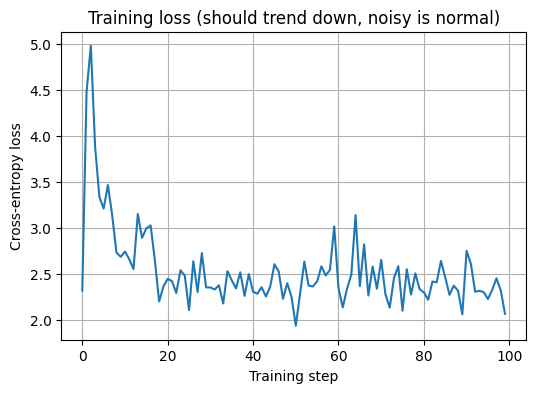

In [16]:
# ----------------------------
# 9) Training loop (minimal steps so it runs quickly on CPU)
# ----------------------------
# things we need to do:

# 1. we need to keep track of the training loss and accuracy for each epoch
# 2. put the model in the training mode
# 3. specify the maximum number of steps (this is for convenience)
# 4. loop over the training set

# what is the difference between epoch and step?
# an epoch is one complete pass through the entire training dataset
# a step is one update of the model parameters


loss_history = []                          # To track loss over time
accuracy_history = []                      # To track accuracy over time

# to put the model in training mode
model.train()                             # Set model to training mode
max_steps = 100                          # Limit steps for quick demo

for step, (images, labels) in enumerate(train_loader):
    # immediately break if we reach max_steps
    if step >= max_steps:
        break

    # first make sure images and labels are on the correct device
    images = images.to(device)             # Move images to device (CPU here)
    labels = labels.to(device)             # Move labels to device (CPU here)

    # firsts pass the images to the model we instantiated earlier
    logits = model(images)                 # Forward pass: compute predicted logits
    print(logits)

    # now compute the loss
    loss = criterion(logits, labels)       # Compute loss between logits and true labels

    # zero the gradients before running the backward pass
    optimizer.zero_grad()                  # Clear old gradients (PyTorch accumulates by default)
    # use backprop to compute the gradients for all the trainable parameters
    loss.backward()                         
    # use the optimizer to update the parameters based on the computed gradients
    optimizer.step()                       # Update model parameters

    # record the loss
    loss_history.append(loss.item())       # Store loss value (as a Python float)
    # compute accuracy for this batch
    _, preds = torch.max(logits, dim=1)   # Get predicted class by taking argmax over logits
    correct = (preds == labels).sum().item()  # Count correct predictions
    accuracy = correct / labels.size(0)    # Compute accuracy
    accuracy_history.append(accuracy)      # Store accuracy value

    # print the loss and accuracy every 10 steps
    if (step + 1) % 10 == 0:
        print(f"Step [{step+1}/{max_steps}], Loss: {loss.item():.4f}, Accuracy: {accuracy*100:.2f}%")


# ----------------------------
# 10) Plot loss (so they visually see optimization)
# ----------------------------

plt.figure(figsize=(6, 4))                  # Create a new figure
plt.plot(loss_history)                      # Plot loss over steps
plt.xlabel("Training step")                 # X-axis label
plt.ylabel("Cross-entropy loss")            # Y-axis label
plt.title("Training loss (should trend down, noisy is normal)")  # Title
plt.grid(True)                              # Add grid for readability
plt.show()                                  # Display the plot


You can see that as training goes on (increasing training step), the cross entropy loss decreases!

Next we need to evaluate the model. There are important notes about the evaluation mode:

For inference, not training, you need to put the model in eval mode. When you put a model in eval mode, you are essentially telling pytorch that I'm using the model for inference not training. And when you do that you are asking pytorch to change layer behaviour. **Importantly** model.eval changes the Dropout and BatchNorm layers behaviour:

**Dropout** layer is meant to regularize training.
- Training mode (model.train()):
    - randomly zeroes activations

- Eval mode (model.eval()):
    - dropout is turned off and all activations pass through

**BatchNorm**
BatchNorm uses the statistics of images in the batch to normalize data. you don’t want predictions to depend on batch composition.

- Training mode (model.train()):
    - uses batch statistics (mean/variance of current batch)

- Eval mode (model.eval()):
    - uses stored running averages and batchNorm weights from training


It is important to note that eval mode is not the same as freezing. In eval mode, we simply change the behaviour of some layers (see above). In other words, eval mode simply changes the runtime behaviour of some layers but not others. MOST importantly, eval mode, does not automatically:
- stop gradients
- freeze parameters
- prevent weight updates
- disable backprop

But you usually use torch.no_grad() during testing/evaluation. And you don't have the loss.backward() and optimizer.step() during testing (see the notebook on training). So it is very important to distinguish between eval mode and freezing. AGAIN eval mode does not automatically turn off gradient tracking and it doesn't stop parameter updating automatically. 

In [18]:
# now it's time to evaluate the model on the test set
# ----------------------------
# 11) Evaluation on test set (what "generalization" means)
# ----------------------------

# first we need to put the model in evaluation mode
# this disables dropout and other training-specific layers
model.eval()                                

correct = 0                                 # Count correct predictions
total = 0                                   # Count total predictions

# we also need to disable gradient tracking for evaluation
# we will iterate over the test set in batches
with torch.no_grad():                       # Disable gradient tracking for faster eval
    for images, labels in test_loader:      # Iterate over test batches
        images = images.to(device)          # Move to CPU
        labels = labels.to(device)          # Move to CPU

        logits = model(images)              # Forward pass
        preds = logits.argmax(dim=1)        # Predicted class = index of max logit

        correct += (preds == labels).sum().item()  # Count correct in this batch
        total += labels.size(0)             # Add batch size to total

test_acc = correct / total                  # Compute accuracy (0..1)
print(f"Test accuracy: {test_acc:.3f}")     # Print accuracy

x shape in ClassifierHead forward: torch.Size([20, 3, 224, 224])
tokens shape after encoder: torch.Size([20, 197, 384])
cls token shape: torch.Size([20, 384])
x shape in ClassifierHead forward: torch.Size([20, 3, 224, 224])
tokens shape after encoder: torch.Size([20, 197, 384])
cls token shape: torch.Size([20, 384])
x shape in ClassifierHead forward: torch.Size([20, 3, 224, 224])
tokens shape after encoder: torch.Size([20, 197, 384])
cls token shape: torch.Size([20, 384])
x shape in ClassifierHead forward: torch.Size([20, 3, 224, 224])
tokens shape after encoder: torch.Size([20, 197, 384])
cls token shape: torch.Size([20, 384])
x shape in ClassifierHead forward: torch.Size([20, 3, 224, 224])
tokens shape after encoder: torch.Size([20, 197, 384])
cls token shape: torch.Size([20, 384])
x shape in ClassifierHead forward: torch.Size([20, 3, 224, 224])
tokens shape after encoder: torch.Size([20, 197, 384])
cls token shape: torch.Size([20, 384])
x shape in ClassifierHead forward: torch.Size(

# Creating and using checkpoints

What are checkpoints? 

A checkpoint is a snapshot of a model’s parameters at a specific point in training. Training is expensive, fragile, and iterative — checkpoints let us stop, resume, reuse, and compare models.

## using state_dict

This will create a dictionary and save the weights and learnable parameters. This doesn't save the architecture, only the parameters. It's called a state_dict for a reason. It's a "state" of the model and you can later on load it into your architecture and the model will behave as it would at the time of saving the state_dict. 


## saving the whole architecture as a serialized model

With torch.save you can save the whole model as a checkpoint. The model will be saved as a serialized object. And so there are downsides to this:
- It depends on your exact Python class existing in the same environment
- If you rename files/classes or change code, loading can break
- It’s less portable across projects
- It can be unsafe to load pickled objects from untrusted sources


So saving the weights and parameters using state_dict, instantiating a model (as a class) and then loading the parameters into that instantiation is safer. 

In [31]:
# Only saving the encoder weights, not the whole model, since the head is just a simple linear layer that can be easily reinitialized for different tasks.
# ----------------------------
tmp_dict = model.encoder.state_dict()  # Get the state dictionary of the model (contains all parameters)
# torch.save(model.encoder.state_dict(), "vit_encoder.pt")

for key in tmp_dict.keys():
    print(key)


# get the weights of the qkv projection layer in the first block of the encoder
# move it to CPU and convert to numpy array for inspection
arr = tmp_dict["patch_embed.cls_token"].cpu().numpy()
print(type(arr))  # Print the type of the array
print(arr.shape)  # Print the shape of the array
# so state_dict is a dictionary that contains all the learnable parameters of the model
# the keys are the names of the parameters and the values are the actual tensors

patch_embed.cls_token
patch_embed.pos_embed
patch_embed.proj.weight
blocks.0.norm1.weight
blocks.0.norm1.bias
blocks.0.attn.qkv.weight
blocks.0.attn.proj.weight
blocks.0.attn.proj.bias
blocks.0.norm2.weight
blocks.0.norm2.bias
blocks.0.mlp.fc1.weight
blocks.0.mlp.fc1.bias
blocks.0.mlp.fc2.weight
blocks.0.mlp.fc2.bias
blocks.1.norm1.weight
blocks.1.norm1.bias
blocks.1.attn.qkv.weight
blocks.1.attn.proj.weight
blocks.1.attn.proj.bias
blocks.1.norm2.weight
blocks.1.norm2.bias
blocks.1.mlp.fc1.weight
blocks.1.mlp.fc1.bias
blocks.1.mlp.fc2.weight
blocks.1.mlp.fc2.bias
blocks.2.norm1.weight
blocks.2.norm1.bias
blocks.2.attn.qkv.weight
blocks.2.attn.proj.weight
blocks.2.attn.proj.bias
blocks.2.norm2.weight
blocks.2.norm2.bias
blocks.2.mlp.fc1.weight
blocks.2.mlp.fc1.bias
blocks.2.mlp.fc2.weight
blocks.2.mlp.fc2.bias
blocks.3.norm1.weight
blocks.3.norm1.bias
blocks.3.attn.qkv.weight
blocks.3.attn.proj.weight
blocks.3.attn.proj.bias
blocks.3.norm2.weight
blocks.3.norm2.bias
blocks.3.mlp.fc1.wei

In [21]:
# How to load the weights back into a model?
# 1. Create a new instance of the model architecture (must match the one used for
#    saving the weights).
# 2. Load the state dictionary from the file.
# 3. Use the load_state_dict() method to load the weights into the model instance

# create a new instance of the encoder
new_encoder = VisionEncoder(
    img_size=224,
    patch_size=16,
    in_chans=3,
    embed_dim=384,
    num_heads=12,
    depth=12,
)

# new_encoder.load_state_dict(torch.load("vit_encoder.pt"))   # 2) load the tensors into it


odict_keys(['encoder.patch_embed.cls_token', 'encoder.patch_embed.pos_embed', 'encoder.patch_embed.proj.weight', 'encoder.blocks.0.norm1.weight', 'encoder.blocks.0.norm1.bias', 'encoder.blocks.0.attn.qkv.weight', 'encoder.blocks.0.attn.proj.weight', 'encoder.blocks.0.attn.proj.bias', 'encoder.blocks.0.norm2.weight', 'encoder.blocks.0.norm2.bias', 'encoder.blocks.0.mlp.fc1.weight', 'encoder.blocks.0.mlp.fc1.bias', 'encoder.blocks.0.mlp.fc2.weight', 'encoder.blocks.0.mlp.fc2.bias', 'encoder.blocks.1.norm1.weight', 'encoder.blocks.1.norm1.bias', 'encoder.blocks.1.attn.qkv.weight', 'encoder.blocks.1.attn.proj.weight', 'encoder.blocks.1.attn.proj.bias', 'encoder.blocks.1.norm2.weight', 'encoder.blocks.1.norm2.bias', 'encoder.blocks.1.mlp.fc1.weight', 'encoder.blocks.1.mlp.fc1.bias', 'encoder.blocks.1.mlp.fc2.weight', 'encoder.blocks.1.mlp.fc2.bias', 'encoder.blocks.2.norm1.weight', 'encoder.blocks.2.norm1.bias', 'encoder.blocks.2.attn.qkv.weight', 'encoder.blocks.2.attn.proj.weight', 'encod

In [ ]:
# saving the model: architecture + weights
# torch.save(model.state_dict(), "vit_full_model.pt")  # saves only the parameters

# loading the full model
# my_model = torch.load("vit_full_model.pt")  # this will load the state dictionary (parameters) into a new model instance

# you can do a forward pass with the new model to check if the weights are loaded correctly
# output = my_model(x)